# Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,precision_recall_curve, auc, mean_squared_error)
from scipy.stats import pearsonr
import krippendorff
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

C:\Users\ahmad\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\ahmad\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


# Define Paths and Load Dataset

In [13]:
# Define paths (use raw strings for Windows paths)
images_dir = r"D:\Study Material\semester 9\DL\ass-1\DL_Assignment1_Dataset\Dataset\Dataset\images"
ann_dir = r"D:\Study Material\semester 9\DL\ass-1\DL_Assignment1_Dataset\Dataset\Dataset\annotations"

# List all image files and extract IDs
image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
ids = [int(f.split('.jpg')[0]) for f in image_files]

# Load labels and filter valid samples
exps, vals, aros, valid_ids, image_paths = [], [], [], [], []
for id_ in ids:
    try:
        exp_path = os.path.join(ann_dir, f"{id_}_exp.npy")
        val_path = os.path.join(ann_dir, f"{id_}_val.npy")
        aro_path = os.path.join(ann_dir, f"{id_}_aro.npy")
        
        # Load with np.load (binary .npy) and cast
        exp = int(np.load(exp_path))
        val = float(np.load(val_path))
        aro = float(np.load(aro_path))
        
        # Filter out invalid (val or aro == -2)
        if val != -2 and aro != -2:
            exps.append(exp)
            vals.append(val)
            aros.append(aro)
            valid_ids.append(id_)
            image_paths.append(os.path.join(images_dir, f"{id_}.jpg"))
    except Exception as e:
        print(f"Error loading annotations for ID {id_}: {e}")
        continue

# Create DataFrame
df = pd.DataFrame({
    'id': valid_ids,
    'exp': exps,
    'val': vals,
    'aro': aros,
    'image_path': image_paths
})

print(f"Loaded {len(df)} valid samples.")
df.head()

Loaded 3999 valid samples.


,id,exp,val,aro,image_path
0,0,0,-0.176846,-0.077640,D:\Study Material\semester 9\DL\ass-1\DL_Assig...
1,1,0,-0.367789,0.183895,D:\Study Material\semester 9\DL\ass-1\DL_Assig...
2,10,7,-0.648471,0.658149,D:\Study Material\semester 9\DL\ass-1\DL_Assig...
3,100,3,0.150794,0.666667,D:\Study Material\semester 9\DL\ass-1\DL_Assig...
4,1001,0,-0.135501,0.004839,D:\Study Material\semester 9\DL\ass-1\DL_Assig...


In [4]:
# step 3

In [14]:
# Split: 80% train, 10% val, 10% test (stratify on exp)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['exp'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['exp'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 3199, Val: 400, Test: 400


In [7]:
# step 4 Define Custom Data Generator

In [15]:
class MultiOutputGenerator(Sequence):
    """Custom generator for multi-task learning: expression classification + valence/arousal regression."""
    
    def __init__(self, df, batch_size=32, shuffle=True, augmentation=False, preprocess_func=None):
        """
        Args:
            df: DataFrame with 'image_path', 'exp', 'val', 'aro'.
            batch_size: int.
            shuffle: bool.
            augmentation: bool - apply data augmentation.
            preprocess_func: function - model-specific preprocessing (e.g., vgg_preprocess).
        """
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.preprocess = preprocess_func
        if augmentation:
            self.datagen = ImageDataGenerator(
                rotation_range=20,
                width_shift_range=0.2,
                height_shift_range=0.2,
                horizontal_flip=True,
                zoom_range=0.2
            )
        else:
            self.datagen = ImageDataGenerator()
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))
    
    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        X = np.empty((self.batch_size, 224, 224, 3))
        y_exp = np.empty((self.batch_size, 8))  # One-hot for 8 classes
        y_val = np.empty((self.batch_size,))
        y_aro = np.empty((self.batch_size,))
        
        for i, idx in enumerate(batch_indices):
            # Load image
            img = cv2.imread(self.df['image_path'][idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # To RGB
            
            # Apply augmentation if enabled
            img = self.datagen.random_transform(img)
            
            # Preprocess (expects [0,255])
            if self.preprocess:
                img = self.preprocess(img.astype('float32'))
            else:
                img = img / 255.0
            
            X[i] = img
            
            # Labels
            y_exp[i] = to_categorical(self.df['exp'][idx], num_classes=8)
            y_val[i] = self.df['val'][idx]
            y_aro[i] = self.df['aro'][idx]
        
        return X, {'exp_out': y_exp, 'val_out': y_val, 'aro_out': y_aro}

In [8]:
# step 5  Define Model Builder Function

In [16]:
def build_multi_task_model(base_model_class, preprocess_func, trainable=False):
    """
    Builds a multi-task model with classification and regression heads.
    
    Args:
        base_model_class: e.g., VGG16.
        preprocess_func: For consistency (though used in generator).
        trainable: bool - whether to fine-tune the base.
    
    Returns:
        Compiled Keras Model.
    """
    base = base_model_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = trainable
    
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    # Heads
    exp_out = Dense(8, activation='softmax', name='exp_out')(x)
    val_out = Dense(1, activation='linear', name='val_out')(x)
    aro_out = Dense(1, activation='linear', name='aro_out')(x)
    
    model = Model(inputs=base.input, outputs=[exp_out, val_out, aro_out])
    
    # Compile
    losses = {'exp_out': 'categorical_crossentropy', 'val_out': 'mse', 'aro_out': 'mse'}
    metrics = {'exp_out': 'accuracy', 'val_out': 'mae', 'aro_out': 'mae'}
    optimizer = Adam(learning_rate=0.001 if not trainable else 1e-5)  # Lower LR for fine-tuning
    model.compile(optimizer=optimizer, loss=losses, metrics=metrics)
    
    return model

In [9]:
# step 6  Train and Evaluate Baselines

In [17]:
# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

# Function to train a model
def train_and_evaluate(base_class, preprocess_func, name):
    print(f"Training {name}...")
    
    # Generators
    batch_size = 32
    train_gen = MultiOutputGenerator(train_df, batch_size=batch_size, shuffle=True, augmentation=True, preprocess_func=preprocess_func)
    val_gen = MultiOutputGenerator(val_df, batch_size=batch_size, shuffle=False, augmentation=False, preprocess_func=preprocess_func)
    
    # Build and train frozen
    model = build_multi_task_model(base_class, preprocess_func, trainable=False)
    start_time = time.time()
    history = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=callbacks)
    frozen_time = time.time() - start_time
    
    # Fine-tune
    model = build_multi_task_model(base_class, preprocess_func, trainable=True)  # Rebuild with trainable=True
    start_time = time.time()
    fine_history = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=callbacks)
    fine_time = time.time() - start_time
    
    total_time = frozen_time + fine_time
    
    # Plot training graphs
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'] + fine_history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'] + fine_history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'{name} Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['exp_out_accuracy'] + fine_history.history['exp_out_accuracy'], label='Train Acc')
    plt.plot(history.history['val_exp_out_accuracy'] + fine_history.history['val_exp_out_accuracy'], label='Val Acc')
    plt.legend()
    plt.title(f'{name} Accuracy')
    plt.show()
    
    return model, total_time, history.history | fine_history.history  # Merge histories


Training VGG16...
58889256/58889256 [==============================] - 16s 0us/step
Epoch 1/20
99/99 [==============================] - 1097s 11s/step - loss: 8.0705 - exp_out_loss: 2.8057 - val_out_loss: 2.9302 - aro_out_loss: 2.3346 - exp_out_accuracy: 0.1402 - val_out_mae: 1.1125 - aro_out_mae: 1.0008 - val_loss: 2.7578 - val_exp_out_loss: 2.0421 - val_val_out_loss: 0.4093 - val_aro_out_loss: 0.3064 - val_exp_out_accuracy: 0.1901 - val_val_out_mae: 0.5223 - val_aro_out_mae: 0.4437
Epoch 2/20
99/99 [==============================] - 881s 9s/step - loss: 2.6869 - exp_out_loss: 2.0848 - val_out_loss: 0.3471 - aro_out_loss: 0.2550 - exp_out_accuracy: 0.1664 - val_out_mae: 0.4729 - aro_out_mae: 0.4095 - val_loss: 2.4972 - val_exp_out_loss: 1.9935 - val_val_out_loss: 0.2916 - val_aro_out_loss: 0.2121 - val_exp_out_accuracy: 0.2057 - val_val_out_mae: 0.4426 - val_aro_out_mae: 0.3737
Epoch 3/20
99/99 [==============================] - 757s 8s/step - loss: 2.5223 - exp_out_loss: 2.0436 - val

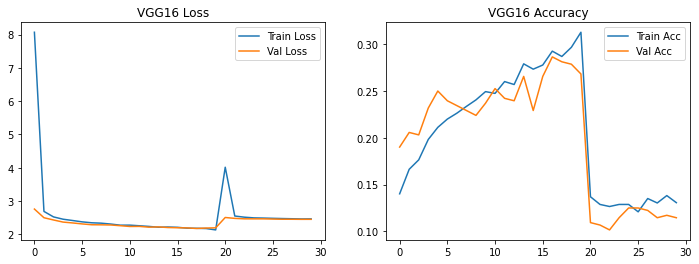

In [18]:
# Train VGG16
vgg_model, vgg_time, vgg_history = train_and_evaluate(VGG16, vgg_preprocess, 'VGG16')



Training ResNet50...
Epoch 1/20
99/99 [==============================] - 329s 3s/step - loss: 4.5280 - exp_out_loss: 2.1891 - val_out_loss: 1.8206 - aro_out_loss: 0.5183 - exp_out_accuracy: 0.1310 - val_out_mae: 0.7115 - aro_out_mae: 0.5077 - val_loss: 2.4516 - val_exp_out_loss: 2.0754 - val_val_out_loss: 0.2187 - val_aro_out_loss: 0.1575 - val_exp_out_accuracy: 0.1484 - val_val_out_mae: 0.3781 - val_aro_out_mae: 0.3481
Epoch 2/20
99/99 [==============================] - 327s 3s/step - loss: 2.4632 - exp_out_loss: 2.0648 - val_out_loss: 0.2334 - aro_out_loss: 0.1649 - exp_out_accuracy: 0.1591 - val_out_mae: 0.3942 - aro_out_mae: 0.3450 - val_loss: 2.4079 - val_exp_out_loss: 2.0374 - val_val_out_loss: 0.2181 - val_aro_out_loss: 0.1525 - val_exp_out_accuracy: 0.2083 - val_val_out_mae: 0.3843 - val_aro_out_mae: 0.3425
Epoch 3/20
99/99 [==============================] - 348s 4s/step - loss: 2.4179 - exp_out_loss: 2.0285 - val_out_loss: 0.2264 - aro_out_loss: 0.1631 - exp_out_accuracy: 0.18

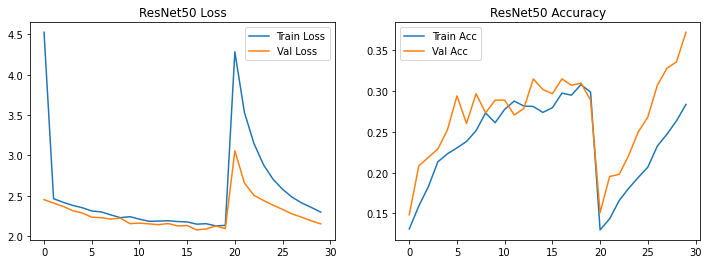

In [19]:
# Train ResNet50
res_model, res_time, res_history = train_and_evaluate(ResNet50, resnet_preprocess, 'ResNet50')

In [20]:
# Step 7: Load Test Data into Arrays and Predict

In [21]:
# Load test data (no generator needed for eval)
def load_test_data(df, preprocess_func):
    X = []
    for path in df['image_path']:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_func(img.astype('float32'))
        X.append(img)
    X = np.array(X)
    y_exp = to_categorical(df['exp'], num_classes=8)
    y_val = df['val'].values
    y_aro = df['aro'].values
    return X, y_exp, y_val, y_aro

# For VGG
X_test_vgg, y_exp_test, y_val_test, y_aro_test = load_test_data(test_df, vgg_preprocess)

pred_exp_vgg, pred_val_vgg, pred_aro_vgg = vgg_model.predict(X_test_vgg)
pred_exp_vgg_class = np.argmax(pred_exp_vgg, axis=1)
pred_val_vgg = pred_val_vgg.flatten()
pred_aro_vgg = pred_aro_vgg.flatten()

# For ResNet (re-preprocess)
X_test_res, _, _, _ = load_test_data(test_df, resnet_preprocess)

pred_exp_res, pred_val_res, pred_aro_res = res_model.predict(X_test_res)
pred_exp_res_class = np.argmax(pred_exp_res, axis=1)
pred_val_res = pred_val_res.flatten()
pred_aro_res = pred_aro_res.flatten()

true_class = test_df['exp'].values

13/13 [==============================] - 30s 2s/step


In [22]:
# Step 8: Define and Compute Evaluation Metrics

In [23]:
# Custom metrics
def concordance_correlation_coefficient(y_true, y_pred):
    """CCC metric."""
    mu_true, mu_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    corr = pearsonr(y_true, y_pred)[0]
    numerator = 2 * corr * np.sqrt(var_true * var_pred)
    denominator = var_true + var_pred + (mu_true - mu_pred)**2
    return numerator / denominator

def sign_agreement_metric(y_true, y_pred):
    """SAGR: Proportion of sign agreement (simple version, as per description)."""
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# Function to compute all metrics for a model
def compute_metrics(true_class, pred_class, y_exp_onehot, pred_exp_prob, y_val, pred_val, y_aro, pred_aro):
    # Categorical
    acc = accuracy_score(true_class, pred_class)
    f1 = f1_score(true_class, pred_class, average='macro')
    kappa = cohen_kappa_score(true_class, pred_class)
    alpha = krippendorff.alpha(np.vstack([true_class, pred_class]))
    roc_auc = roc_auc_score(y_exp_onehot, pred_exp_prob, multi_class='ovr')
    
    pr_auc = 0
    for i in range(8):
        precision, recall, _ = precision_recall_curve(y_exp_onehot[:, i], pred_exp_prob[:, i])
        pr_auc += auc(recall, precision)
    pr_auc /= 8
    
    # Continuous (average val and aro for simplicity, or report separate)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
    corr_val = pearsonr(y_val, pred_val)[0]
    sagr_val = sign_agreement_metric(y_val, pred_val)
    ccc_val = concordance_correlation_coefficient(y_val, pred_val)
    
    rmse_aro = np.sqrt(mean_squared_error(y_aro, pred_aro))
    corr_aro = pearsonr(y_aro, pred_aro)[0]
    sagr_aro = sign_agreement_metric(y_aro, pred_aro)
    ccc_aro = concordance_correlation_coefficient(y_aro, pred_aro)
    
    return {
        'acc': acc, 'f1': f1, 'kappa': kappa, 'alpha': alpha, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
        'rmse_val': rmse_val, 'corr_val': corr_val, 'sagr_val': sagr_val, 'ccc_val': ccc_val,
        'rmse_aro': rmse_aro, 'corr_aro': corr_aro, 'sagr_aro': sagr_aro, 'ccc_aro': ccc_aro
    }

# Compute for VGG
vgg_metrics = compute_metrics(true_class, pred_exp_vgg_class, y_exp_test, pred_exp_vgg, y_val_test, pred_val_vgg, y_aro_test, pred_aro_vgg)

# Compute for ResNet
res_metrics = compute_metrics(true_class, pred_exp_res_class, y_exp_test, pred_exp_res, y_val_test, pred_val_res, y_aro_test, pred_aro_res)

# Display comparison table
comparison_df = pd.DataFrame({'VGG16': vgg_metrics, 'ResNet50': res_metrics}).T
print(comparison_df)

# Also print times
print(f"VGG16 Training Time: {vgg_time:.2f} seconds")
print(f"ResNet50 Training Time: {res_time:.2f} seconds")

             acc        f1     kappa     alpha   roc_auc    pr_auc  rmse_val  \
VGG16     0.1325  0.065682  0.008571  0.105531  0.520693  0.142709  0.468053   
ResNet50  0.2925  0.269604  0.191429  0.117367  0.732757  0.310695  0.469726   

          corr_val  sagr_val   ccc_val  rmse_aro  corr_aro  sagr_aro   ccc_aro  
VGG16     0.107152    0.6900  0.020273  0.381681  0.029787    0.7925  0.012013  
ResNet50  0.365728    0.6825  0.349678  0.397718  0.256434    0.7650  0.242113  
VGG16 Training Time: 41000.83 seconds
ResNet50 Training Time: 18732.57 seconds


In [24]:
# step 9: Visualize Correct/Incorrect Classifications

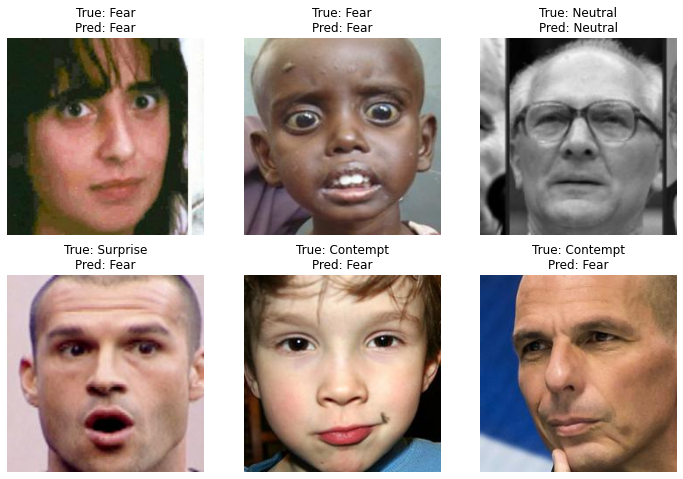

In [25]:
# Find correct and incorrect indices (using VGG for example)
correct_idx = np.where(pred_exp_vgg_class == true_class)[0][:3]  # First 3 correct
incorrect_idx = np.where(pred_exp_vgg_class != true_class)[0][:3]  # First 3 incorrect

# Expression labels
exp_labels = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, idx in enumerate(correct_idx):
    img = plt.imread(test_df['image_path'].iloc[idx])
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"True: {exp_labels[true_class[idx]]}\nPred: {exp_labels[pred_exp_vgg_class[idx]]}")
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Correct')

for i, idx in enumerate(incorrect_idx):
    img = plt.imread(test_df['image_path'].iloc[idx])
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"True: {exp_labels[true_class[idx]]}\nPred: {exp_labels[pred_exp_vgg_class[idx]]}")
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Incorrect')
plt.show()

# CNN

In [ ]:
# Custom CNN class
class CustomCNN(keras.Model):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3))
        self.pool1 = keras.layers.MaxPooling2D((2,2))
        self.conv2 = keras.layers.Conv2D(64, (3,3), activation='relu')
        self.pool2 = keras.layers.MaxPooling2D((2,2))
        self.flatten = keras.layers.Flatten()
        self.dense = Dense(128, activation='relu')
        self.dropout = Dropout(0.5)
        self.exp_out = Dense(8, activation='softmax', name='exp_out')
        self.val_out = Dense(1, activation='linear', name='val_out')
        self.aro_out = Dense(1, activation='linear', name='aro_out')
    
    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.dense(x)
        x = self.dropout(x)
        return [self.exp_out(x), self.val_out(x), self.aro_out(x)]

# Build and train (use no preprocess or simple /255)
custom_model = CustomCNN()
custom_model.compile(optimizer=Adam(1e-3), loss={'exp_out': 'categorical_crossentropy', 'val_out': 'mse', 'aro_out': 'mse'}, metrics={'exp_out': 'accuracy', 'val_out': 'mae', 'aro_out': 'mae'})

# Generators with no preprocess (or add lambda x: x/255.0)
train_gen_custom = MultiOutputGenerator(train_df, augmentation=True)
val_gen_custom = MultiOutputGenerator(val_df, augmentation=False)

custom_history = custom_model.fit(train_gen_custom, validation_data=val_gen_custom, epochs=20, callbacks=callbacks)

# Evaluate similarly (add to comparison)